In [94]:
# Cell 1: Import libraries

from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully. ✅")

All libraries imported successfully. ✅


In [95]:
# Cell 2: Define project paths

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishing_features.csv"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

MODEL_PATH = (
    MODEL_DIR
    / "random_forest.joblib"
)

METADATA_PATH = (
    MODEL_DIR
    / "model_metadata.json"
)

CONFUSION_MATRIX_PATH = (
    RESULTS_DIR
    / "confusion_matrix_rf.png"
)

FEATURE_IMPORTANCE_PATH = (
    RESULTS_DIR
    / "feature_importance.png"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nFeature dataset:")
print(DATA_PATH)

Project root:
c:\Users\Manid\project1

Feature dataset:
c:\Users\Manid\project1\data\processed\phishing_features.csv


In [96]:
# Cell 3: Verify feature dataset

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"\nFeature dataset not found:\n{DATA_PATH}\n\n"
        "Run 03_feature_engineering.ipynb first."
    )

print("Feature dataset found. ✅")

Feature dataset found. ✅


In [97]:
# Cell 4: Create required directories

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model and results directories are ready. ✅")

Model and results directories are ready. ✅


In [98]:
# Cell 5: Load engineered features

df = pd.read_csv(
    DATA_PATH
)

print("Feature dataset loaded. ✅")

print(
    f"Rows    : {len(df):,}"
)

print(
    f"Columns : {len(df.columns):,}"
)

Feature dataset loaded. ✅
Rows    : 235,795
Columns : 24


In [99]:
# Cell 6: Inspect dataset

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset shape:
(235795, 24)

Columns:
['url_length', 'dot_count', 'hyphen_count', 'underscore_count', 'slash_count', 'digit_count', 'letter_count', 'special_character_count', 'has_https', 'has_http', 'has_at_symbol', 'has_ip_address', 'suspicious_keyword_count', 'url_entropy', 'has_query', 'has_fragment', 'has_percent_encoding', 'has_suspicious_double_slash', 'hostname_length', 'subdomain_count', 'hostname_digit_count', 'hostname_hyphen_count', 'suspicious_tld', 'label']


In [100]:
# Cell 7: Define target column

TARGET_COLUMN = "label"

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' "
        "was not found."
    )

print(
    f"Target column: {TARGET_COLUMN}"
)

Target column: label


In [101]:
# Cell 8: Separate X and y

X = df.drop(
    columns=[TARGET_COLUMN]
).copy()

y = df[TARGET_COLUMN].copy()

print(
    f"Feature matrix X: {X.shape}"
)

print(
    f"Target vector y : {y.shape}"
)

Feature matrix X: (235795, 23)
Target vector y : (235795,)


In [102]:
# Cell 9: Validate feature data types

non_numeric_columns = (
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)

if non_numeric_columns:
    raise TypeError(
        "Non-numeric columns found:\n"
        f"{non_numeric_columns}"
    )

print(
    "All model features are numerical. ✅"
)

All model features are numerical. ✅


In [103]:
# Cell 10: Validate feature values

if X.isnull().any().any():
    raise ValueError(
        "Missing values detected in X."
    )

if not np.isfinite(
    X.to_numpy(dtype=float)
).all():
    raise ValueError(
        "Infinite values detected in X."
    )

print(
    "No missing or infinite feature values. ✅"
)

No missing or infinite feature values. ✅


In [104]:
# Cell 11: Validate target labels

unique_labels = sorted(
    y.unique()
)

print(
    "Unique labels:",
    unique_labels
)

if not set(unique_labels).issubset({0, 1}):
    raise ValueError(
        f"Unexpected labels: {unique_labels}"
    )

print(
    "Target labels are valid. ✅"
)

Unique labels: [np.int64(0), np.int64(1)]
Target labels are valid. ✅


In [105]:
# Cell 12: Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test split completed. ✅")

print(
    f"\nTraining samples: {len(X_train):,}"
)

print(
    f"Testing samples : {len(X_test):,}"
)

Train/Test split completed. ✅

Training samples: 188,636
Testing samples : 47,159


In [106]:
# Cell 13: Check train/test label distribution

print("Training distribution:")
print(
    y_train.value_counts(
        normalize=True
    ).sort_index()
)

print("\nTesting distribution:")
print(
    y_test.value_counts(
        normalize=True
    ).sort_index()
)

Training distribution:
label
0    0.428105
1    0.571895
Name: proportion, dtype: float64

Testing distribution:
label
0    0.428105
1    0.571895
Name: proportion, dtype: float64


In [107]:
# Cell 14: Create Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created. ✅")

Random Forest model created. ✅


In [108]:
# Cell 15: Train Random Forest

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed. ✅")

Training Random Forest...
Random Forest training completed. ✅


In [109]:
# Cell 16: Generate predictions

y_pred = rf_model.predict(
    X_test
)

y_probability = rf_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated. ✅")

Predictions generated. ✅


In [110]:
# Cell 17: Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)
print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9950
Accuracy: 99.50%


In [111]:
# Cell 18: Calculate precision

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

print(
    f"Precision: {precision:.4f}"
)

Precision: 0.9937


In [112]:
# Cell 19: Calculate recall

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

print(
    f"Recall: {recall:.4f}"
)

Recall: 0.9976


In [113]:
# Cell 20: Calculate F1 score

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

print(
    f"F1-score: {f1:.4f}"
)

F1-score: 0.9956


In [114]:
# Cell 21: Calculate ROC-AUC

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

ROC-AUC: 0.9968


In [115]:
# Cell 22: Classification report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Phishing",
            "Legitimate"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           0.99     47159
   macro avg       1.00      0.99      0.99     47159
weighted avg       0.99      0.99      0.99     47159



In [116]:
# Cell 23: Phishing recall

phishing_recall = recall_score(
    y_test,
    y_pred,
    pos_label=0,
    zero_division=0
)

print(
    f"Phishing Recall: "
    f"{phishing_recall:.4f}"
)

print(
    f"Phishing Recall: "
    f"{phishing_recall * 100:.2f}%"
)

Phishing Recall: 0.9915
Phishing Recall: 99.15%


In [117]:
# Cell 24: Create confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20018   171]
 [   66 26904]]


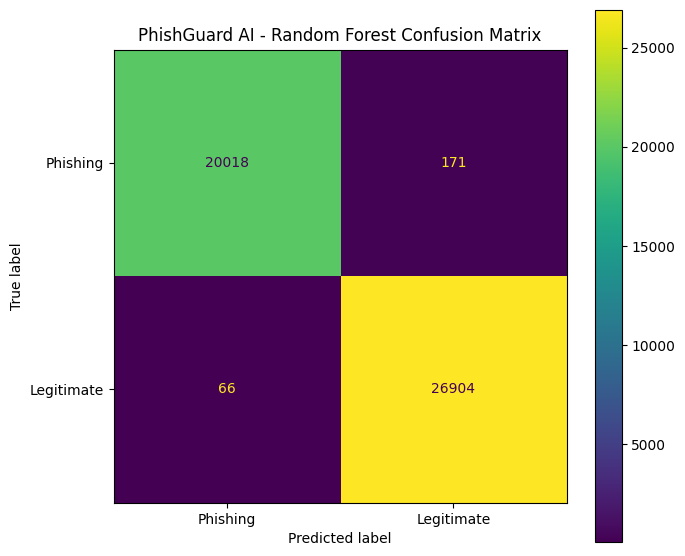

Saved to:
c:\Users\Manid\project1\results\confusion_matrix_rf.png


In [118]:
# Cell 25: Visualize confusion matrix

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "PhishGuard AI - Random Forest Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved to:\n{CONFUSION_MATRIX_PATH}"
)

In [119]:
# Cell 26: Calculate feature importance

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance
0,slash_count,0.229958
1,has_http,0.224591
2,has_https,0.192562
3,special_character_count,0.069990
4,digit_count,0.067247
5,url_length,0.046975
6,url_entropy,0.035067
7,hostname_digit_count,0.026557
8,letter_count,0.022656
9,subdomain_count,0.022272


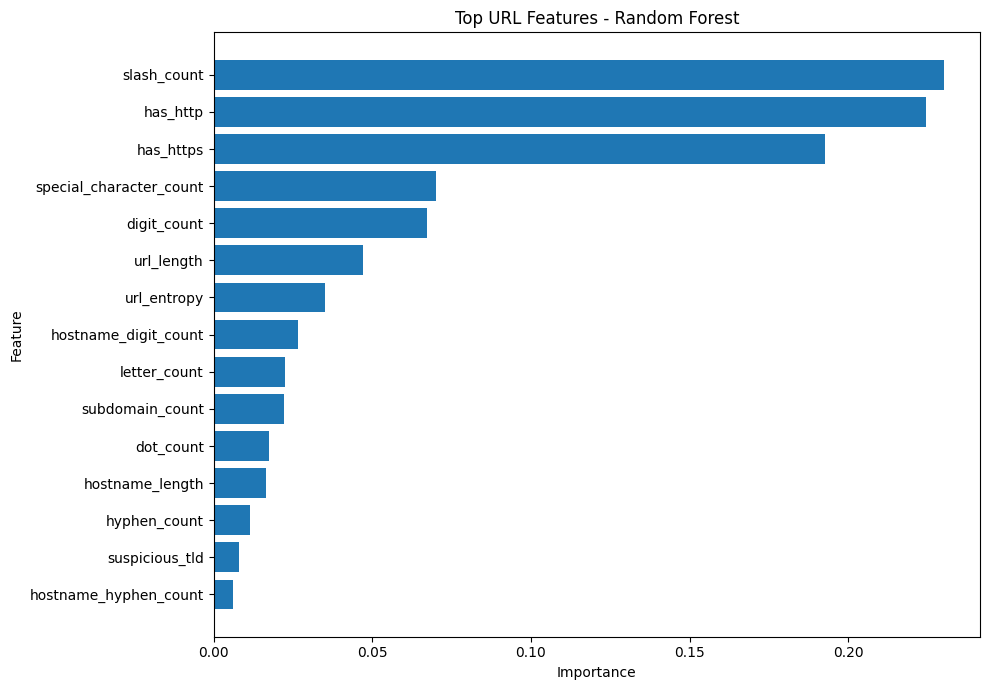

Saved to:
c:\Users\Manid\project1\results\feature_importance.png


In [120]:
# Cell 27: Visualize feature importance

top_n = 15

top_features = (
    importance_df
    .head(top_n)
    .sort_values(
        "importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top URL Features - Random Forest"
)

plt.tight_layout()

plt.savefig(
    FEATURE_IMPORTANCE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved to:\n{FEATURE_IMPORTANCE_PATH}"
)

In [121]:
# Cell 28: Save trained model

joblib.dump(
    rf_model,
    MODEL_PATH
)

print(
    "Random Forest model saved successfully. ✅"
)

print(
    f"\nModel path:\n{MODEL_PATH}"
)

Random Forest model saved successfully. ✅

Model path:
c:\Users\Manid\project1\models\random_forest.joblib


In [122]:
# Cell 29: Save model metadata

metadata = {
    "model": "RandomForestClassifier",
    "random_state": 42,
    "n_estimators": 300,
    "test_size": 0.20,
    "target_column": TARGET_COLUMN,
    "label_mapping": {
        "0": "Phishing",
        "1": "Legitimate"
    },
    "features": X.columns.tolist(),
    "number_of_features": len(X.columns),
    "metrics": {
        "accuracy": float(accuracy),
        "precision_legitimate": float(precision),
        "recall_legitimate": float(recall),
        "f1_legitimate": float(f1),
        "phishing_recall": float(phishing_recall),
        "roc_auc": float(roc_auc)
    }
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    "Model metadata saved successfully. ✅"
)

print(
    f"\nMetadata path:\n{METADATA_PATH}"
)

Model metadata saved successfully. ✅

Metadata path:
c:\Users\Manid\project1\models\model_metadata.json


In [123]:
# Cell 30: Reload saved model

loaded_rf_model = joblib.load(
    MODEL_PATH
)

reloaded_predictions = (
    loaded_rf_model.predict(X_test)
)

same_predictions = np.array_equal(
    y_pred,
    reloaded_predictions
)

print(
    "Model reload successful. ✅"
)

print(
    "Predictions identical:",
    same_predictions
)

Model reload successful. ✅
Predictions identical: True


In [124]:
# Cell 31: Final model summary

print("=" * 70)
print("PHISHGUARD AI - RANDOM FOREST COMPLETE")
print("=" * 70)

print(
    f"Training samples : {len(X_train):,}"
)

print(
    f"Testing samples  : {len(X_test):,}"
)

print(
    f"Features         : {X.shape[1]}"
)

print(
    f"Accuracy         : {accuracy * 100:.2f}%"
)

print(
    f"F1-score         : {f1:.4f}"
)

print(
    f"ROC-AUC          : {roc_auc:.4f}"
)

print(
    f"Phishing Recall  : "
    f"{phishing_recall * 100:.2f}%"
)

print("\nGenerated files:")

print(
    f"✓ {MODEL_PATH}"
)

print(
    f"✓ {METADATA_PATH}"
)

print(
    f"✓ {CONFUSION_MATRIX_PATH}"
)

print(
    f"✓ {FEATURE_IMPORTANCE_PATH}"
)

print("\nRandom Forest pipeline completed successfully. ✅")

PHISHGUARD AI - RANDOM FOREST COMPLETE
Training samples : 188,636
Testing samples  : 47,159
Features         : 23
Accuracy         : 99.50%
F1-score         : 0.9956
ROC-AUC          : 0.9968
Phishing Recall  : 99.15%

Generated files:
✓ c:\Users\Manid\project1\models\random_forest.joblib
✓ c:\Users\Manid\project1\models\model_metadata.json
✓ c:\Users\Manid\project1\results\confusion_matrix_rf.png
✓ c:\Users\Manid\project1\results\feature_importance.png

Random Forest pipeline completed successfully. ✅


In [125]:
from pathlib import Path
import os

print("Current notebook directory:")
print(Path.cwd())

print("\nCurrent project root:")
print(PROJECT_ROOT)

print("\nMODEL_PATH:")
print(MODEL_PATH)

print("\nDoes MODEL_PATH exist?")
print(MODEL_PATH.exists())

if MODEL_PATH.exists():
    print("\nActual file size:")
    print(MODEL_PATH.stat().st_size, "bytes")

print("\nFiles inside models folder:")

if MODEL_DIR.exists():
    for file in MODEL_DIR.iterdir():
        print(
            file.name,
            "->",
            file.stat().st_size,
            "bytes"
        )
else:
    print("models folder does not exist")

Current notebook directory:
c:\Users\Manid\project1\notebooks

Current project root:
c:\Users\Manid\project1

MODEL_PATH:
c:\Users\Manid\project1\models\random_forest.joblib

Does MODEL_PATH exist?
True

Actual file size:
59324393 bytes

Files inside models folder:
ann_model.pth -> 63756 bytes
ann_model_metadata.json -> 1498 bytes
ann_scaler.joblib -> 1775 bytes
model_metadata.json -> 1228 bytes
random_forest.joblib -> 59324393 bytes


In [126]:
import joblib

loaded_model = joblib.load(MODEL_PATH)

print("Random Forest loaded successfully! ✅")
print("Number of trees:", loaded_model.n_estimators)
print("Number of features:", loaded_model.n_features_in_)

Random Forest loaded successfully! ✅
Number of trees: 300
Number of features: 23
